The following architecture uses 3x3 kernel sizes because they allow the network to stack multiple non-linear activations. For the filters, I started with 32 and then doubled them to 64 and 128 after each block; because increase in channel depth allows the network to capture increasingly complex features as it goes deeper.

The results attahced are from 2 attempts. The first one was overfitting at an accuracy of just 78 percent at the 9th epoch. To avoid that in the next attempt I added batch normilazation and data augmentaion to prevent the model from just simply memorising the training set features instead if finding oatterns in them. This helped me reach 78 percent on just the 4th epoch and improved the accuracy to 87 percent with 20 epochs.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [2]:

#Using GPU if avalilable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


EPOCHS = 15
BATCH_SIZE = 64
LR = 0.001

# Pipeline 1
# Normalising the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Grab the datasets
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


class SimpleVGG(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: 32 filters
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 2: 64 filters
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Block 3: 128 filters
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dense layers at the end
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),  # Image shrinks: 32x32 -> 16x16 -> 8x8 -> 4x4
            nn.ReLU(),
            nn.Dropout(0.5), # Drop some connections to prevent overfitting
            nn.Linear(512, 10) # 10 classes in CIFAR-10
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        return self.fc_layers(x)




100%|██████████| 170M/170M [06:25<00:00, 442kB/s]


In [4]:
#Training
model = SimpleVGG().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Trackers for our plot
train_loss_history = []
val_loss_history = []

print(f"Training on {device}")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    #Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    # No gradients needed for validation
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    avg_val_loss = val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)
    acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Accuracy: {acc:.2f}%")

print(f"Training finished! Final Test Accuracy: {acc:.2f}%")



Training on cuda
Epoch 1/15 | Train Loss: 1.6095 | Val Loss: 1.2443 | Accuracy: 53.04%
Epoch 2/15 | Train Loss: 1.1282 | Val Loss: 0.9796 | Accuracy: 64.69%
Epoch 3/15 | Train Loss: 0.9204 | Val Loss: 0.8347 | Accuracy: 69.74%
Epoch 4/15 | Train Loss: 0.7702 | Val Loss: 0.7350 | Accuracy: 74.44%
Epoch 5/15 | Train Loss: 0.6640 | Val Loss: 0.7360 | Accuracy: 74.59%
Epoch 6/15 | Train Loss: 0.5863 | Val Loss: 0.6870 | Accuracy: 76.35%
Epoch 7/15 | Train Loss: 0.5190 | Val Loss: 0.6699 | Accuracy: 77.98%
Epoch 8/15 | Train Loss: 0.4599 | Val Loss: 0.6711 | Accuracy: 77.68%
Epoch 9/15 | Train Loss: 0.4053 | Val Loss: 0.7007 | Accuracy: 78.32%
Epoch 10/15 | Train Loss: 0.3624 | Val Loss: 0.7091 | Accuracy: 78.46%
Epoch 11/15 | Train Loss: 0.3359 | Val Loss: 0.7218 | Accuracy: 78.84%
Epoch 12/15 | Train Loss: 0.2988 | Val Loss: 0.7738 | Accuracy: 77.87%
Epoch 13/15 | Train Loss: 0.2779 | Val Loss: 0.7743 | Accuracy: 78.68%
Epoch 14/15 | Train Loss: 0.2550 | Val Loss: 0.8263 | Accuracy: 79.00

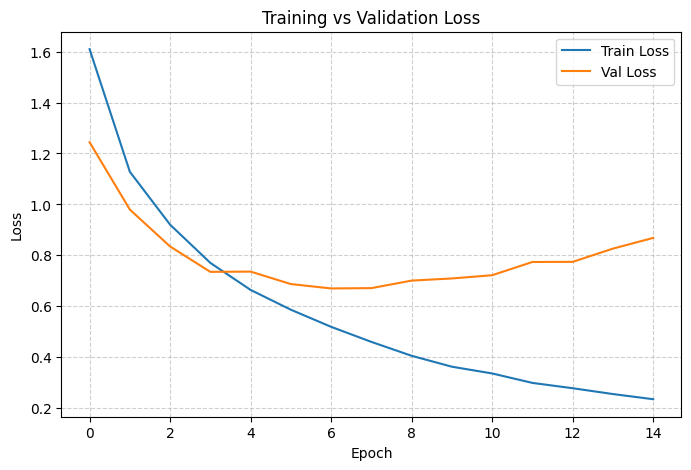

In [5]:
# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('loss_curve.png')
plt.show()

In [11]:
# Pipeline 2: Improved (With data augmentation)
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set_2 = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
train_loader_2 = torch.utils.data.DataLoader(train_set_2, batch_size=64, shuffle=True)


class SimpleVGG2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def train_model(model, train_loader, optimizer, epochs, model_name):
    criterion = nn.CrossEntropyLoss()
    train_hist, val_hist = [], []
    epochs = 20

    print(f"\nStarting Training: {model_name} ")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_hist.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        avg_val_loss = val_loss / len(test_loader)
        val_hist.append(avg_val_loss)
        acc = 100 * correct / total

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {acc:.2f}%")

    return train_hist, val_hist, acc

# Train Improved
model_improved = SimpleVGG2().to(device)

opt_improved = optim.Adam(model_improved.parameters(), lr=0.001, weight_decay=1e-4)
imp_train_loss, imp_val_loss, imp_acc = train_model(
    model_improved, train_loader_2, opt_improved, EPOCHS, "ImprovedVGG (BatchNorm + Augmentation)"
)


Starting Training: ImprovedVGG (BatchNorm + Augmentation) 
Epoch 1/20 | Train Loss: 1.2722 | Val Loss: 1.1937 | Acc: 62.11%
Epoch 2/20 | Train Loss: 0.8625 | Val Loss: 0.7535 | Acc: 73.57%
Epoch 3/20 | Train Loss: 0.7401 | Val Loss: 0.6570 | Acc: 77.32%
Epoch 4/20 | Train Loss: 0.6583 | Val Loss: 0.6389 | Acc: 78.10%
Epoch 5/20 | Train Loss: 0.6028 | Val Loss: 0.6541 | Acc: 77.76%
Epoch 6/20 | Train Loss: 0.5578 | Val Loss: 0.5134 | Acc: 82.62%
Epoch 7/20 | Train Loss: 0.5275 | Val Loss: 0.4827 | Acc: 83.53%
Epoch 8/20 | Train Loss: 0.5004 | Val Loss: 0.5398 | Acc: 82.00%
Epoch 9/20 | Train Loss: 0.4735 | Val Loss: 0.4862 | Acc: 83.02%
Epoch 10/20 | Train Loss: 0.4516 | Val Loss: 0.4770 | Acc: 84.02%
Epoch 11/20 | Train Loss: 0.4306 | Val Loss: 0.4994 | Acc: 83.05%
Epoch 12/20 | Train Loss: 0.4195 | Val Loss: 0.4846 | Acc: 83.28%
Epoch 13/20 | Train Loss: 0.4000 | Val Loss: 0.4359 | Acc: 85.33%
Epoch 14/20 | Train Loss: 0.3913 | Val Loss: 0.4100 | Acc: 86.15%
Epoch 15/20 | Train Loss:

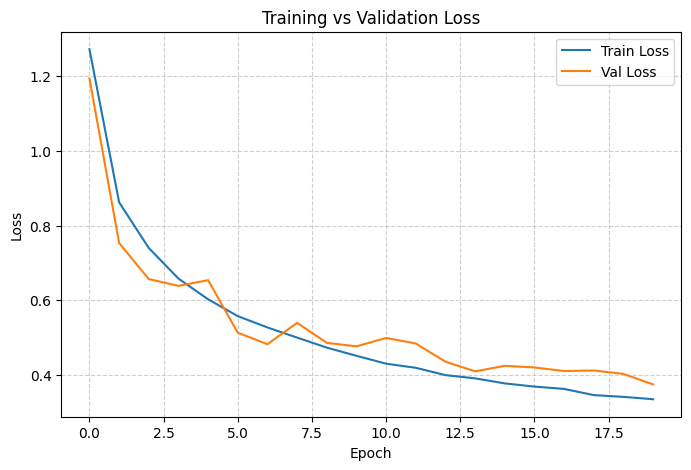

In [12]:

# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(imp_train_loss, label='Train Loss')
plt.plot(imp_val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('loss_curve.png')
plt.show()